# Figure 4a: Sigmoidal GSH depletion (biological extension)

Companion to **Figure 4**. Where `Figure-4-glutathione-depletion-tipping-point.ipynb`
plots ExposoGraph's linear `interaction_engine.gsh_depletion_model()`, this
notebook plots the package's sibling function
`interaction_engine.gsh_depletion_biology_model()` &mdash; the same input
contract, but with feedback-inhibited synthesis and Michaelis&ndash;Menten
saturable consumption. Both models live in the package; this notebook
compares them on the same axes.

**Why a separate notebook**

- The linear model's equation `1 - consumption / (synthesis + natural_turnover)`
  is dominated by `synthesis` (40 vs ~1.5 &micro;mol/h/g), so it collapses to a
  piecewise-linear ramp that hits zero exactly at `consumption = synthesis`.
  Defensible as a didactic toy, but it doesn't capture two features of
  hepatic GSH dynamics:
  1. The transition through the impairment threshold is smooth, not a
     hard knee.
  2. The pool stabilises at a non-zero floor under sustained heavy
     exposure, because once GSH falls, &gamma;-glutamylcysteine ligase
     (&gamma;-GCS) feedback is de-repressed and synthesis ramps up.

**What this notebook does**

- Calls `gsh_depletion_biology_model()` from the package on the same `load`
  grid as Figure 4 (translating `load` to total consumption rate via the
  linear model's calibration of ~9.673 &micro;mol/h/g per load unit).
- Re-derives the linear curve from `gsh_depletion_model()` for direct overlay.
- For each scenario (wild-type / GCLC 70% synthesis / GCLM 50% synthesis)
  runs both models at every load.
- Plots steady-state response and the rate-balance picture that produces the
  sigmoidal shape.

**Caveats**

- Biology parameters live in `ExposoGraph/data/interaction_parameters.json`
  under `gsh_depletion.biology_model`: `Ki_feedback_mM = 1.5`,
  `n_feedback = 2`, `Km_GST_mM = 3.5`. `Ki` is literature-grounded
  (Richman & Meister 1975, ~1.5&ndash;2.3 mM); `Km_GST` is an apparent in-vivo
  value chosen so wild-type biology G_ss matches the linear model's
  30%-impairment anchor at the same total consumption rate.
- GCLC/GCLM curves use `synthesis_scale = 0.70 / 0.50` on the biology model
  (a built-in keyword) and the same scaling on the linear model's
  `synthesis_rate_umol_h_g` (matching the original Figure 4 convention).

In [1]:
from __future__ import annotations

import csv
import json
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "ExposoGraph").is_dir() and (candidate / "pyproject.toml").exists():
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate the ExposoGraph repository root.")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from ExposoGraph.interaction_engine import (
    gsh_depletion_biology_model,
    gsh_depletion_model,
)

OUTPUT_DIR = REPO_ROOT / "Figures_Notebook" / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PARAMETER_FILE = REPO_ROOT / "ExposoGraph" / "data" / "interaction_parameters.json"
with PARAMETER_FILE.open("r", encoding="utf-8") as handle:
    INTERACTION_PARAMS = json.load(handle)

GSH_PARAMS = INTERACTION_PARAMS["gsh_depletion"]
BIOLOGY_PARAMS = GSH_PARAMS["biology_model"]

BASELINE_GSH_MM = float(GSH_PARAMS["baseline_gsh_mM"])
PACKAGE_SYNTHESIS_RATE = float(GSH_PARAMS["synthesis_rate_umol_h_g"])
HALF_LIFE_H = float(GSH_PARAMS.get("half_life_h", 2.5))
CRITICAL_THRESHOLD = float(GSH_PARAMS["critical_threshold_fraction"])
IMPAIRMENT_THRESHOLD = 0.30
LIVER_WATER_FRACTION = 0.70

K_TURNOVER = math.log(2) / HALF_LIFE_H
KI_MM = float(BIOLOGY_PARAMS["Ki_feedback_mM"])
N_FEEDBACK = float(BIOLOGY_PARAMS["n_feedback"])
KM_MM = float(BIOLOGY_PARAMS["Km_GST_mM"])

# Linear model's load -> consumption mapping (matches Figure 4 exactly).
BASELINE_UMOL_G = BASELINE_GSH_MM * LIVER_WATER_FRACTION
NATURAL_TURNOVER = BASELINE_UMOL_G * math.log(2) / HALF_LIFE_H
REFERENCE_LOAD = 3.0
CONSUMPTION_PER_LOAD = (
    (1.0 - IMPAIRMENT_THRESHOLD)
    * (PACKAGE_SYNTHESIS_RATE + NATURAL_TURNOVER)
    / REFERENCE_LOAD
)
LOAD_GRID = np.linspace(0.0, 5.0, 401)

print(f"Baseline GSH         : {BASELINE_GSH_MM} mM")
print(f"Half-life            : {HALF_LIFE_H} h  ->  k = {K_TURNOVER:.4f} /h")
print(f"Linear synthesis     : {PACKAGE_SYNTHESIS_RATE} umol/h/g")
print(f"Biology Ki           : {KI_MM} mM   (Hill n = {N_FEEDBACK})")
print(f"Biology Km (GST)     : {KM_MM} mM")
print(f"Critical threshold   : {CRITICAL_THRESHOLD:.0%}")
print(f"Impairment cutoff    : {IMPAIRMENT_THRESHOLD:.0%}")
print(f"Consumption per load : {CONSUMPTION_PER_LOAD:.3f} umol/h/g per unit")

Baseline GSH         : 7.5 mM
Half-life            : 2.5 h  ->  k = 0.2773 /h
Linear synthesis     : 40.0 umol/h/g
Biology Ki           : 1.5 mM   (Hill n = 2.0)
Biology Km (GST)     : 3.5 mM
Critical threshold   : 20%
Impairment cutoff    : 30%
Consumption per load : 9.673 umol/h/g per unit


## The biological extensions

Three changes the package's `gsh_depletion_biology_model()` makes relative to
the linear `gsh_depletion_model()`:

1. **Feedback-inhibited synthesis.** &gamma;-GCS is product-inhibited by GSH. As the
   pool drops, synthesis ramps up.

   $$V_\text{synth}(G) = \frac{V_\text{max}}{1 + (G/K_i)^n}$$

   where $V_\text{max}$ is set internally by mass balance at baseline
   ($V_\text{synth}(G_\text{baseline}) = k\cdot G_\text{baseline}$).

2. **First-order natural turnover.** Same as the linear model: $k\cdot G$
   with $k = \ln(2)/t_{1/2}$.

3. **Saturable consumption.** GST conjugation follows Michaelis&ndash;Menten in GSH;
   the rate the caller passes in is interpreted as the G-saturated upper bound.

   $$V_\text{cons}(G) = V_\text{cons,max}\cdot \frac{G}{K_m + G}$$

The steady state $V_\text{synth}(G) = k\cdot G + V_\text{cons}(G)$ has no
closed form; the package solves it by bisection.

GCLC/GCLM scenarios are passed directly via the
`synthesis_scale` keyword on `gsh_depletion_biology_model()`.

In [2]:
SCENARIOS = [
    {"name": "Wild-type", "scale": 1.00,
     "color": "#007c89", "linestyle": "-"},
    {"name": "GCLC variant (70% synthesis)", "scale": 0.70,
     "color": "#d89c00", "linestyle": "--"},
    {"name": "GCLM variant (50% synthesis)", "scale": 0.50,
     "color": "#b65a32", "linestyle": "-."},
]


def linear_curve(load: float, synthesis_scale: float) -> float:
    """Reproduce gsh_depletion_model() with a scaled synthesis rate.

    The package function does not accept a synthesis_scale, so we recompute
    the steady-state fraction with the rescaled parameters directly &mdash; this
    matches the original Figure 4 convention for the GCLC/GCLM curves.
    """
    synthesis = PACKAGE_SYNTHESIS_RATE * synthesis_scale
    consumption = load * CONSUMPTION_PER_LOAD
    if consumption <= 0:
        return 1.0
    if consumption >= synthesis:
        return 0.0
    return max(0.0, 1.0 - consumption / (synthesis + NATURAL_TURNOVER))


def biology_curve(load: float, synthesis_scale: float) -> float:
    """Call the package's biology model on the same consumption rate."""
    consumption = load * CONSUMPTION_PER_LOAD
    status = gsh_depletion_biology_model(
        {"BPDE_umol_h_g": consumption},
        synthesis_scale=synthesis_scale,
    )
    return status.fraction_normal


curve_rows = []
for scenario in SCENARIOS:
    for load in LOAD_GRID:
        bio = biology_curve(float(load), scenario["scale"])
        lin = linear_curve(float(load), scenario["scale"])
        curve_rows.append({
            "scenario": scenario["name"],
            "synthesis_scale": scenario["scale"],
            "relative_exposure_load": round(float(load), 4),
            "biology_gsh_remaining_percent": round(bio * 100.0, 3),
            "linear_gsh_remaining_percent": round(lin * 100.0, 3),
        })

curve_csv = OUTPUT_DIR / "figure4a_gsh_biology_vs_linear.csv"
with curve_csv.open("w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(handle, fieldnames=list(curve_rows[0].keys()))
    writer.writeheader()
    writer.writerows(curve_rows)

print(curve_csv)
print()
print(f"{'Load':>5} | {'WT bio':>7} {'WT lin':>7} | {'GCLC bio':>9} {'GCLC lin':>9} | {'GCLM bio':>9} {'GCLM lin':>9}")
print("-" * 72)
for q in [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]:
    parts = [f"{q:>5.1f} |"]
    for sc in SCENARIOS:
        b = biology_curve(q, sc["scale"]) * 100
        l = linear_curve(q, sc["scale"]) * 100
        parts.append(f" {b:>6.1f}% {l:>6.1f}% |")
    print("".join(parts))

/Users/julhashkazi/Documents/ExposoGraph_work/Figures_Notebook/output/figure4a_gsh_biology_vs_linear.csv

 Load |  WT bio  WT lin |  GCLC bio  GCLC lin |  GCLM bio  GCLM lin
------------------------------------------------------------------------
  0.0 |  100.0%  100.0% |   88.5%  100.0% |   78.8%  100.0% |
  0.5 |   61.3%   88.3% |   52.7%   83.6% |   45.6%   77.5% |
  1.0 |   48.0%   76.7% |   40.9%   67.2% |   35.0%   54.9% |
  1.5 |   40.7%   65.0% |   34.5%   50.7% |   29.3%   32.4% |
  2.0 |   36.0%   53.3% |   30.3%   34.3% |   25.5%    9.8% |
  2.5 |   32.5%   41.7% |   27.2%   17.9% |   22.7%    0.0% |
  3.0 |   29.8%   30.0% |   24.8%    0.0% |   20.6%    0.0% |
  3.5 |   27.7%   18.3% |   22.9%    0.0% |   18.9%    0.0% |
  4.0 |   25.9%    6.7% |   21.3%    0.0% |   17.4%    0.0% |
  4.5 |   24.3%    0.0% |   19.9%    0.0% |   16.2%    0.0% |
  5.0 |   23.0%    0.0% |   18.7%    0.0% |   15.1%    0.0% |


## Where the sigmoid comes from: rate balance

At a fixed `total_consumption`, the steady state is the intersection of the
**synthesis** curve (decreasing in `G`, due to feedback) and the **total-loss**
curve (turnover + saturable consumption, increasing in `G`). For low
consumption the intersection sits near baseline GSH; as consumption rises,
the loss curve shifts up and the intersection slides down, but only until
the consumption term saturates and synthesis ramps up. The two effects
together pin a non-zero floor &mdash; there is no `consumption = synthesis` cliff.

The rate curves below are computed locally from the same `Ki`, `n`, `Km`
constants the package reads, so this panel and panel (a) describe the same
model.

In [3]:
# Anchor V_max via mass balance at baseline (matches what the package does)
G_baseline = BASELINE_GSH_MM
feedback_at_baseline = 1.0 + (G_baseline / KI_MM) ** N_FEEDBACK
V_MAX_SYNTH_MM_PER_H = K_TURNOVER * G_baseline * feedback_at_baseline


def synth_at_G(G_mM: float) -> float:
    return V_MAX_SYNTH_MM_PER_H / (1.0 + (G_mM / KI_MM) ** N_FEEDBACK)


def turnover_at_G(G_mM: float) -> float:
    return K_TURNOVER * G_mM


def consumption_at_G(G_mM: float, total_consumption_mM_per_h: float) -> float:
    if G_mM <= 0:
        return 0.0
    return total_consumption_mM_per_h * G_mM / (KM_MM + G_mM)


G_GRID = np.linspace(1e-3, 1.05 * BASELINE_GSH_MM, 401)
LOAD_PROBES = [1.0, 3.0, 5.0]
# Convert each load's umol/h/g consumption to mM/h to plot in concentration units
LOAD_CONS_MM = [
    L * CONSUMPTION_PER_LOAD / LIVER_WATER_FRACTION for L in LOAD_PROBES
]

rate_rows = []
for load, cons_mM in zip(LOAD_PROBES, LOAD_CONS_MM):
    for G in G_GRID:
        rate_rows.append({
            "load": load,
            "total_consumption_mM_per_h": round(cons_mM, 4),
            "G_mM": round(float(G), 5),
            "synthesis_mM_per_h": round(synth_at_G(float(G)), 6),
            "turnover_mM_per_h": round(turnover_at_G(float(G)), 6),
            "consumption_mM_per_h": round(consumption_at_G(float(G), cons_mM), 6),
            "loss_total_mM_per_h": round(
                turnover_at_G(float(G)) + consumption_at_G(float(G), cons_mM), 6
            ),
        })

rate_csv = OUTPUT_DIR / "figure4a_rate_balance.csv"
with rate_csv.open("w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(handle, fieldnames=list(rate_rows[0].keys()))
    writer.writeheader()
    writer.writerows(rate_rows)

print(rate_csv)
print(f"V_max_synth (anchored from JSON params): {V_MAX_SYNTH_MM_PER_H:.3f} mM/h")

/Users/julhashkazi/Documents/ExposoGraph_work/Figures_Notebook/output/figure4a_rate_balance.csv
V_max_synth (anchored from JSON params): 54.065 mM/h


## Render Figure 4a

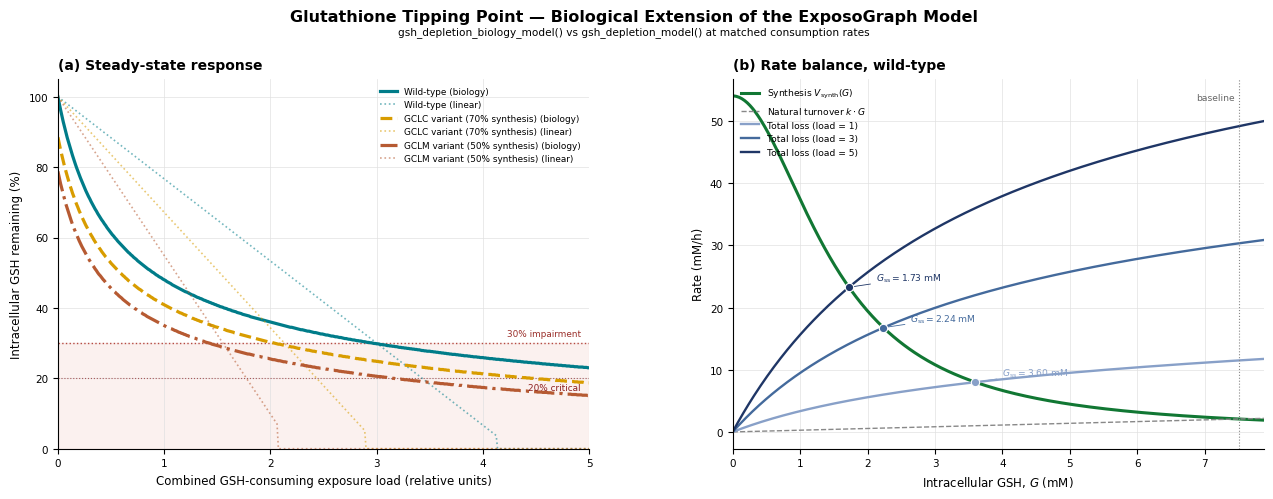

/Users/julhashkazi/Documents/ExposoGraph_work/Figures_Notebook/output/figure4a_gsh_biology_extension.png
/Users/julhashkazi/Documents/ExposoGraph_work/Figures_Notebook/output/figure4a_gsh_biology_extension.pdf
/Users/julhashkazi/Documents/ExposoGraph_work/Figures_Notebook/output/figure4a_gsh_biology_extension.svg


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13.4, 5.6), constrained_layout=False)
fig.subplots_adjust(left=0.07, right=0.97, bottom=0.18, top=0.84, wspace=0.27)

# ---------- Panel (a): steady-state biology vs linear ----------
ax = axes[0]
ax.axhspan(0, IMPAIRMENT_THRESHOLD * 100, color="#f4d7d2", alpha=0.35, zorder=0)
ax.axhline(IMPAIRMENT_THRESHOLD * 100, color="#b44b42", linestyle=":", linewidth=1.0)
ax.axhline(CRITICAL_THRESHOLD * 100, color="#8d1f1f", linestyle=":", linewidth=0.8, alpha=0.7)

for scenario in SCENARIOS:
    rows = [r for r in curve_rows if r["scenario"] == scenario["name"]]
    loads = [r["relative_exposure_load"] for r in rows]
    bio = [r["biology_gsh_remaining_percent"] for r in rows]
    lin = [r["linear_gsh_remaining_percent"] for r in rows]
    ax.plot(loads, bio, color=scenario["color"], linestyle=scenario["linestyle"],
            linewidth=2.3, label=f"{scenario['name']} (biology)")
    ax.plot(loads, lin, color=scenario["color"], linestyle=":", linewidth=1.2,
            alpha=0.55, label=f"{scenario['name']} (linear)")

ax.set_xlim(0, 5)
ax.set_ylim(0, 105)
ax.set_xlabel("Combined GSH-consuming exposure load (relative units)", fontsize=8.5)
ax.set_ylabel("Intracellular GSH remaining (%)", fontsize=8.5)
ax.set_xticks(np.arange(0, 5.1, 1.0))
ax.set_yticks(np.arange(0, 101, 20))
ax.tick_params(axis="both", labelsize=7.5)
ax.grid(color="#e1e1e1", linewidth=0.5)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.text(4.92, IMPAIRMENT_THRESHOLD * 100 + 1.5, "30% impairment",
        fontsize=6.4, color="#9b302b", ha="right", va="bottom")
ax.text(4.92, CRITICAL_THRESHOLD * 100 - 1.5, "20% critical",
        fontsize=6.4, color="#8d1f1f", ha="right", va="top")
ax.legend(loc="upper right", fontsize=6.4, frameon=False, ncol=1)
ax.text(0.0, 1.02, "(a) Steady-state response", transform=ax.transAxes,
        fontsize=10, weight="bold", va="bottom")

# ---------- Panel (b): rate balance for the wild-type model ----------
ax = axes[1]
synth_curve = np.array([synth_at_G(float(G)) for G in G_GRID])
turn_curve = np.array([turnover_at_G(float(G)) for G in G_GRID])

ax.plot(G_GRID, synth_curve, color="#117733", linewidth=2.2,
        label="Synthesis $V_\\mathrm{synth}(G)$")
ax.plot(G_GRID, turn_curve, color="#888888", linewidth=1.0, linestyle="--",
        label="Natural turnover $k\\cdot G$")

load_colors = ["#88a0c8", "#446a9c", "#1f3666"]
for color, load, cons_mM in zip(load_colors, LOAD_PROBES, LOAD_CONS_MM):
    loss_curve = turn_curve + np.array(
        [consumption_at_G(float(G), cons_mM) for G in G_GRID]
    )
    ax.plot(G_GRID, loss_curve, color=color, linewidth=1.7,
            label=f"Total loss (load = {load:g})")
    # Steady state via the package, in mM
    status = gsh_depletion_biology_model(
        {"BPDE_umol_h_g": load * CONSUMPTION_PER_LOAD},
        synthesis_scale=1.0,
    )
    G_ss_mM = status.steady_state_gsh_mM
    rate_at_ss = synth_at_G(G_ss_mM)
    ax.plot(G_ss_mM, rate_at_ss, marker="o", color=color, markersize=6.0,
            zorder=5, markeredgecolor="white", markeredgewidth=0.8)
    ax.annotate(
        f"$G_\\mathrm{{ss}}={G_ss_mM:.2f}$ mM",
        xy=(G_ss_mM, rate_at_ss),
        xytext=(G_ss_mM + 0.4, rate_at_ss + 1.0),
        fontsize=6.6, color=color,
        arrowprops={"arrowstyle": "-", "color": color, "linewidth": 0.6},
    )

ax.axvline(BASELINE_GSH_MM, color="#888", linestyle=":", linewidth=0.8)
ax.text(BASELINE_GSH_MM - 0.05, ax.get_ylim()[1] * 0.96, "baseline",
        fontsize=6.6, color="#666", ha="right", va="top")

ax.set_xlim(0, G_GRID.max())
ax.set_xlabel("Intracellular GSH, $G$ (mM)", fontsize=8.5)
ax.set_ylabel("Rate (mM/h)", fontsize=8.5)
ax.tick_params(axis="both", labelsize=7.5)
ax.grid(color="#e1e1e1", linewidth=0.5)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.legend(loc="upper left", fontsize=6.6, frameon=False)
ax.text(0.0, 1.02, "(b) Rate balance, wild-type", transform=ax.transAxes,
        fontsize=10, weight="bold", va="bottom")

fig.suptitle(
    "Glutathione Tipping Point \u2014 Biological Extension of the ExposoGraph Model",
    fontsize=11.5, weight="bold", y=0.965,
)
fig.text(
    0.5, 0.915,
    "gsh_depletion_biology_model() vs gsh_depletion_model() at matched consumption rates",
    ha="center", va="bottom", fontsize=7.6,
)

png_path = OUTPUT_DIR / "figure4a_gsh_biology_extension.png"
pdf_path = OUTPUT_DIR / "figure4a_gsh_biology_extension.pdf"
svg_path = OUTPUT_DIR / "figure4a_gsh_biology_extension.svg"
fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(svg_path, bbox_inches="tight")
plt.show()

print(png_path)
print(pdf_path)
print(svg_path)